Device: cpu


Using cache found in /Users/abhayatrivedi/.cache/torch/hub/facebookresearch_dinov2_main
Caching features: 100%|█████████████████████████| 20/20 [00:16<00:00,  1.24it/s]


Epoch 1/5 | Val IoU: 0.3697
Epoch 2/5 | Val IoU: 0.3790
Epoch 3/5 | Val IoU: 0.3864
Epoch 4/5 | Val IoU: 0.3910
Epoch 5/5 | Val IoU: 0.3979
Saved to: fast_runs


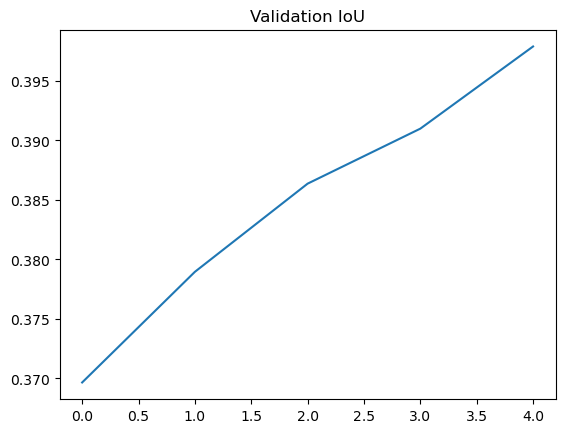

In [12]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# configuration
ROOT = "/Users/abhayatrivedi/Downloads/Offroad_Segmentation_Training_Dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224        
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-3
NUM_CLASSES = 10
SAVE_DIR = "fast_runs"
os.makedirs(SAVE_DIR, exist_ok=True)

# mapping classes 
CLASS_MAP = {
    100: 0, 200: 1, 300: 2, 500: 3, 550: 4,
    600: 5, 700: 6, 800: 7, 7100: 8, 10000: 9
}

class SegDataset(Dataset):
    def __init__(self, root, split):
        self.img_dir = os.path.join(root, split, "Color_Images")
        self.mask_dir = os.path.join(root, split, "Segmentation")
        self.names = sorted(os.listdir(self.img_dir))

        self.img_tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.mask_tf = transforms.Resize(
            (IMG_SIZE, IMG_SIZE),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def encode_mask(self, mask):
        arr = np.array(mask)
        out = np.zeros_like(arr)
        for k, v in CLASS_MAP.items():
            out[arr == k] = v
        return torch.from_numpy(out).long()

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.names[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, self.names[idx]))

        img = self.img_tf(img)
        mask = self.mask_tf(mask)
        mask = self.encode_mask(mask)

        return img, mask

# ground truth mask
def compute_iou(pred, target, num_classes):
    pred = pred.view(-1)
    target = target.view(-1)
    ious = []

    for c in range(num_classes):
        inter = ((pred == c) & (target == c)).sum().item()
        union = ((pred == c) | (target == c)).sum().item()
        if union > 0:
            ious.append(inter / union)

    return np.mean(ious)

def compute_pixel_acc(pred, target):
    return (pred == target).float().mean().item()

class SegHead(nn.Module):
    def __init__(self, in_dim, num_classes, H, W):
        super().__init__()
        self.H, self.W = H, W
        self.net = nn.Sequential(
            nn.Conv2d(in_dim, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        B, N, C = x.shape
        x = x.view(B, self.H, self.W, C).permute(0, 3, 1, 2)
        return self.net(x)

def cache_features(backbone, loader):
    feats, masks = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Caching features"):
            imgs = imgs.to(DEVICE)
            f = backbone.forward_features(imgs)["x_norm_patchtokens"]
            feats.append(f.cpu())
            masks.append(lbls.cpu())
    return torch.cat(feats), torch.cat(masks)

def main():
    print("Device:", DEVICE)

    # Loading datasets
    train_ds = SegDataset(ROOT, "train")
    val_ds = SegDataset(ROOT, "val")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    backbone = torch.hub.load(
        "facebookresearch/dinov2",
        "dinov2_vits14"
    ).to(DEVICE).eval()

    train_feats, train_masks = cache_features(backbone, train_loader)
    val_feats, val_masks = cache_features(backbone, val_loader)

    token_dim = train_feats.shape[-1]
    token_H = IMG_SIZE // 14
    token_W = IMG_SIZE // 14

    # Tensors
    train_data = TensorDataset(train_feats, train_masks)
    val_data = TensorDataset(val_feats, val_masks)

    train_dl = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

    # Model
    model = SegHead(token_dim, NUM_CLASSES, token_H, token_W).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    history = {"train_iou": [], "val_iou": []}

    # Training loop
    for epoch in range(EPOCHS):
        model.train()
        for feats, masks in train_dl:
            feats, masks = feats.to(DEVICE), masks.to(DEVICE)
            logits = model(feats)
            logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
            loss = criterion(logits, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        ious = []
        with torch.no_grad():
            for feats, masks in val_dl:
                feats, masks = feats.to(DEVICE), masks.to(DEVICE)
                out = model(feats)
                out = F.interpolate(out, size=masks.shape[1:], mode="bilinear", align_corners=False)
                preds = out.argmax(1)
                ious.append(compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES))

        val_iou = np.mean(ious)
        history["val_iou"].append(val_iou)
        print(f"Epoch {epoch+1}/{EPOCHS} | Val IoU: {val_iou:.4f}")

    # Saving this modl
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "seg_head.pth"))

    # Plot
    plt.plot(history["val_iou"])
    plt.title("Validation IoU")
    plt.savefig(os.path.join(SAVE_DIR, "iou.png"))

    print("Saved to:", SAVE_DIR)
    return history

if __name__ == "__main__":
    history = main()

Using cache found in /Users/abhayatrivedi/.cache/torch/hub/facebookresearch_dinov2_main
Caching features: 100%|█████████████████████████| 20/20 [00:19<00:00,  1.04it/s]


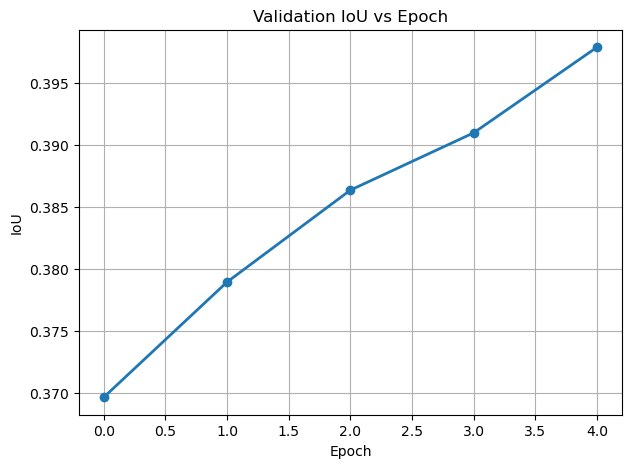

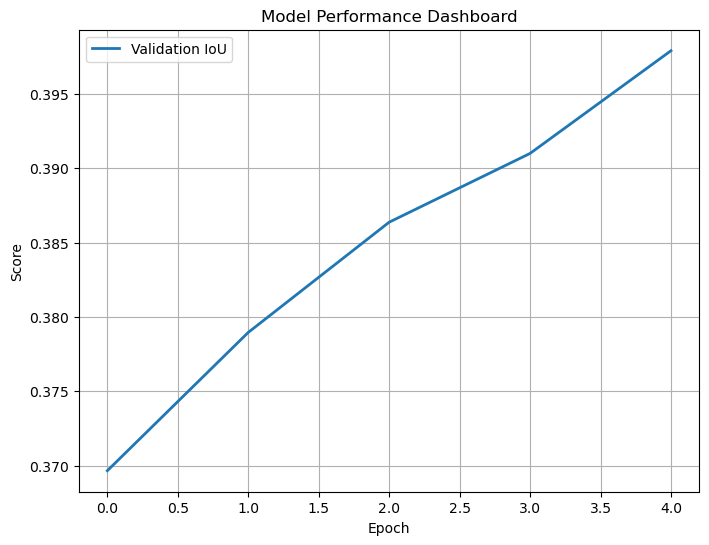

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..1.9602616].


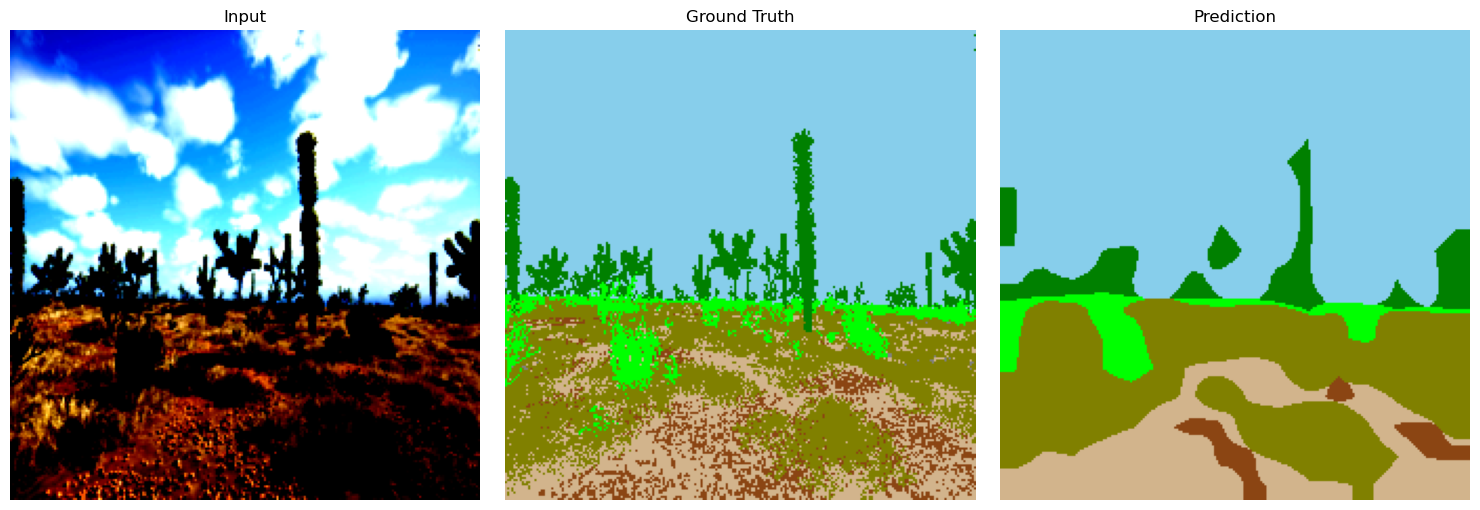

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.3611329].


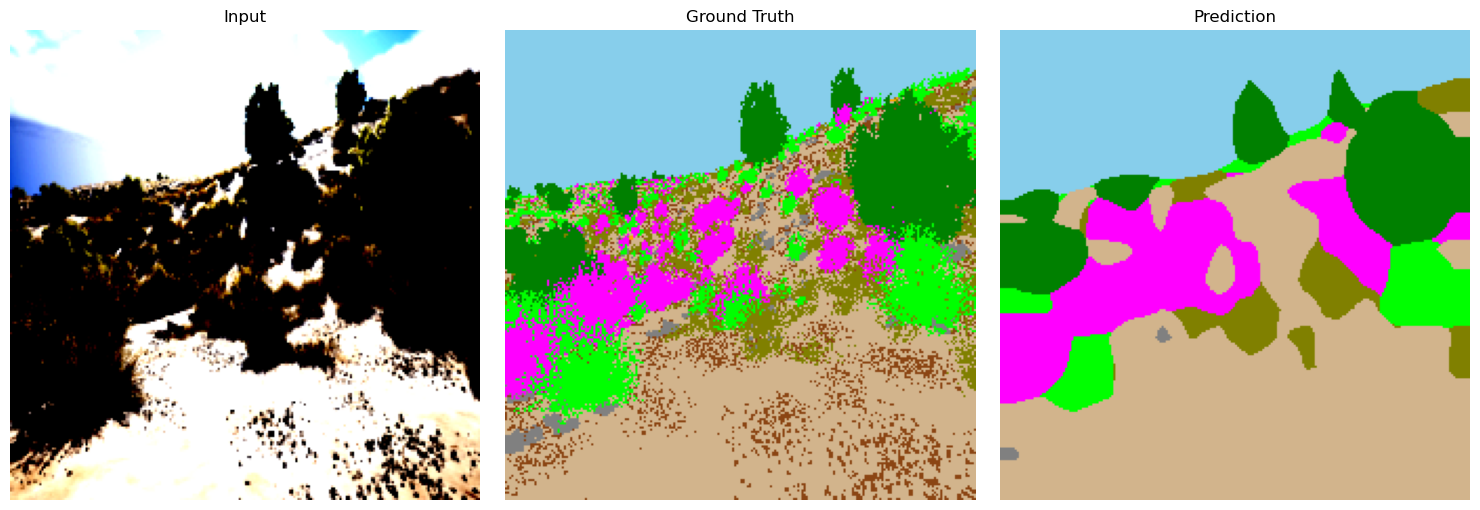

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..1.9602616].


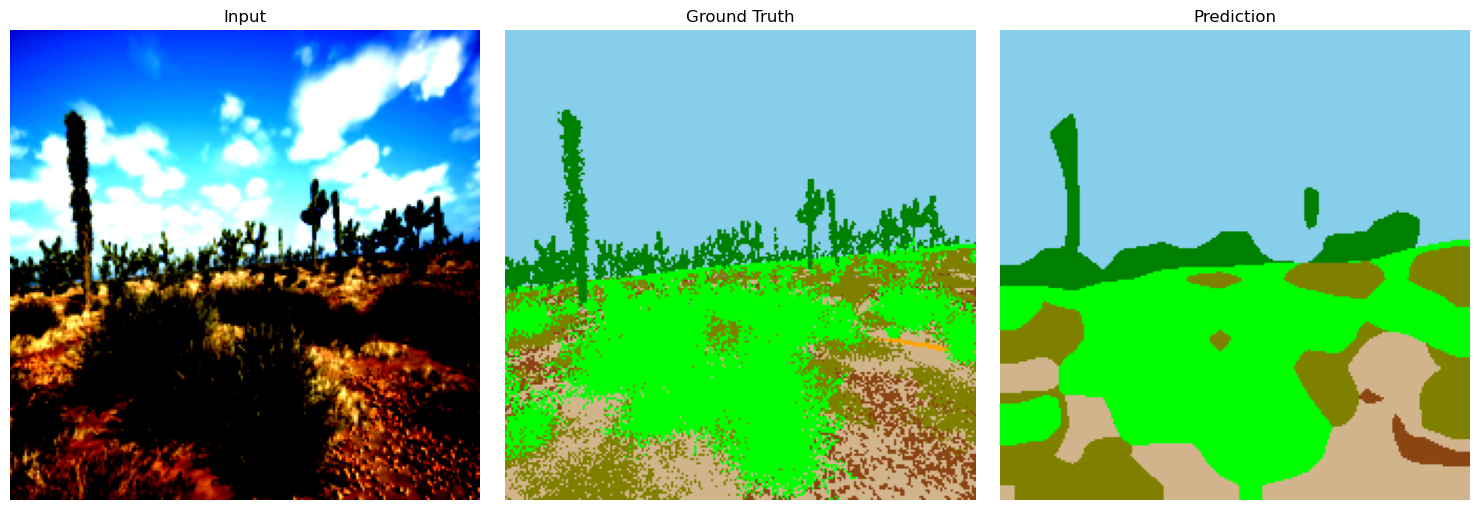

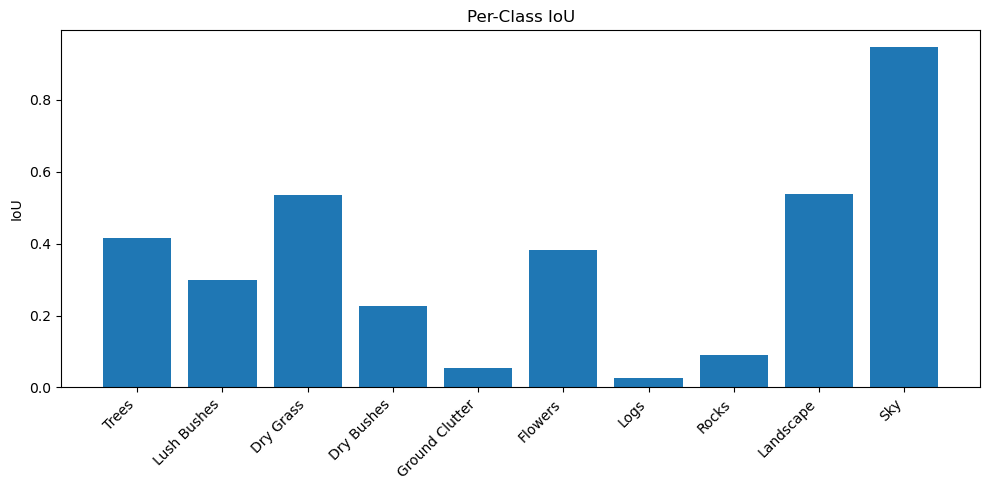


🎉 ALL VISUALIZATIONS GENERATED AND DISPLAYED
📂 Saved in: fast_runs


In [13]:
token_dim = 384  # DINOv2 ViT-S14 embedding dim
token_H = IMG_SIZE // 14
token_W = IMG_SIZE // 14

model = SegHead(token_dim, NUM_CLASSES, token_H, token_W).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "seg_head.pth"), map_location=DEVICE))
model.eval()

# reloading dataset
train_ds = SegDataset(ROOT, "train")
val_ds = SegDataset(ROOT, "val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


backbone = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
).to(DEVICE).eval()

train_feats, train_masks = cache_features(backbone, train_loader)
val_feats, val_masks = cache_features(backbone, val_loader)

#visualisation util

SEG_COLORS = {
    0: [0, 128, 0], 1: [0, 255, 0], 2: [128, 128, 0], 3: [165, 42, 42],
    4: [139, 69, 19], 5: [255, 0, 255], 6: [255, 165, 0],
    7: [128, 128, 128], 8: [210, 180, 140], 9: [135, 206, 235]
}

CLASS_NAMES = [
    "Trees","Lush Bushes","Dry Grass","Dry Bushes","Ground Clutter",
    "Flowers","Logs","Rocks","Landscape","Sky"
]

def colorize_mask(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for k, v in SEG_COLORS.items():
        rgb[mask == k] = v
    return rgb

#IoU curve
plt.figure(figsize=(7,5))
plt.plot(history["val_iou"], marker="o", linewidth=2)
plt.title("Validation IoU vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "val_iou_curve.png"))
plt.show()

#Performance 
plt.figure(figsize=(8,6))
plt.plot(history["val_iou"], label="Validation IoU", linewidth=2)
plt.title("Model Performance Dashboard")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "performance_dashboard.png"))
plt.show()

#Qualitative res
np.random.seed(0)
sample_ids = np.random.choice(len(train_ds), 3, replace=False)

for i, idx in enumerate(sample_ids):
    img, gt = train_ds[idx]

    with torch.no_grad():
        f = train_feats[idx:idx+1].to(DEVICE)
        out = model(f)
        out = F.interpolate(out, size=gt.shape, mode="bilinear", align_corners=False)
        pred = out.argmax(1).squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    ax[0].imshow(img.permute(1,2,0))
    ax[0].set_title("Input")
    ax[1].imshow(colorize_mask(gt.numpy()))
    ax[1].set_title("Ground Truth")
    ax[2].imshow(colorize_mask(pred))
    ax[2].set_title("Prediction")

    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"qualitative_{i}.png"))
    plt.show()

#iou bar chart
iou_per_class = {i: [] for i in range(NUM_CLASSES)}

with torch.no_grad():
    for f, m in zip(val_feats, val_masks):
        f = f.unsqueeze(0).to(DEVICE)
        m = m.unsqueeze(0)

        out = model(f)
        out = F.interpolate(out, size=m.shape[1:], mode="bilinear", align_corners=False)
        pred = out.argmax(1).cpu()

        for c in range(NUM_CLASSES):
            inter = ((pred == c) & (m == c)).sum().item()
            union = ((pred == c) | (m == c)).sum().item()
            if union > 0:
                iou_per_class[c].append(inter / union)

mean_ious = [np.mean(iou_per_class[c]) if iou_per_class[c] else 0 for c in range(NUM_CLASSES)]

plt.figure(figsize=(10,5))
plt.bar(CLASS_NAMES, mean_ious)
plt.xticks(rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("Per-Class IoU")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "per_class_iou.png"))
plt.show()

print("\n🎉 ALL VISUALIZATIONS GENERATED AND DISPLAYED")
print("📂 Saved in:", SAVE_DIR)